# Customer Churn Prediction System
### Phase 5: Evaluate & Improve (Tasks 12-16)

Phase 4 gave us four trained models and raw predictions, but no real judgment on
which one is actually good. This phase scores them properly, picks a winner,
digs into its mistakes and its reasoning, and then tunes it to squeeze out more
performance.

## Setup: rebuilding Phase 3 + Phase 4

Same recap pattern as before -- re-running the prep and training steps so this
notebook stands on its own.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

df = pd.read_csv('customer_churn.csv').drop(columns=['CustomerID'])
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

gender_map = {'Male': 0, 'Female': 1}
X_train_prep['Gender'] = X_train_prep['Gender'].map(gender_map)
X_test_prep['Gender'] = X_test_prep['Gender'].map(gender_map)

categorical_cols = ['Subscription Type', 'Contract Length']
X_train_prep = pd.get_dummies(X_train_prep, columns=categorical_cols, drop_first=True)
X_test_prep = pd.get_dummies(X_test_prep, columns=categorical_cols, drop_first=True)
X_test_prep = X_test_prep.reindex(columns=X_train_prep.columns, fill_value=0)

numeric_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                'Payment Delay', 'Total Spend', 'Last Interaction']
scaler = StandardScaler()
X_train_prep[numeric_cols] = scaler.fit_transform(X_train_prep[numeric_cols])
X_test_prep[numeric_cols] = scaler.transform(X_test_prep[numeric_cols])

# Train all four models (same as Phase 4)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    predictions[name] = model.predict(X_test_prep)

print("Setup complete. All four models trained and predicting on the test set.")

Setup complete. All four models trained and predicting on the test set.


## Task 12: Compare All Four Models Properly

Four metrics, side by side, for every model:
- **Accuracy** -- overall % correct
- **Precision** -- of predicted churners, what % actually churned
- **Recall** -- of actual churners, what % did the model catch
- **F1-score** -- balance of precision and recall in one number

In [3]:
results = []
for name, y_pred in predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df = results_df.sort_values('F1-Score', ascending=False)
results_df

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,0.9981,0.9992,0.9967,0.9979
SVM,0.9456,0.9290,0.9584,0.9434
KNN,0.9170,0.8862,0.9464,0.9153
Logistic Regression,0.8271,0.8138,0.8234,0.8186


In [4]:
best_model_name = results_df.index[0]
print(f"Best model by F1-score: {best_model_name}")
print(f"\n{results_df.loc[best_model_name]}")

Best model by F1-score: Random Forest

Accuracy     0.9981
Precision    0.9992
Recall       0.9967
F1-Score     0.9979
Name: Random Forest, dtype: float64


**A note on these numbers, if Random Forest comes out near 99%+:** that's
unusually high for a real-world churn problem, and it's worth understanding *why*
rather than just reporting it. Recall from Phase 2 that `Payment Delay` and
`Support Calls` didn't just correlate with churn -- they showed sharp, near-cliff
thresholds (churn rate jumping from ~10% to ~70%+ almost like a switch flipping,
not a gradual slope). That kind of clean, rule-like pattern is exactly what
tree-based models like Random Forest can learn almost perfectly. It suggests this
dataset likely follows fairly clean underlying rules -- common in practice/teaching
datasets -- rather than the noisier relationships you'd see in messy real company
data. Worth stating this explicitly in your final write-up (Task 21) as an
observation about the dataset, not just a score to celebrate at face value.

**Why we sort by F1, not accuracy:** F1 balances precision and recall together,
so a model can't win just by leaning hard toward predicting one class. Whichever
model comes out on top above is the one we carry forward for the rest of this
phase.

## Task 13: Confusion Matrix (Best Model)

Breaking the best model's predictions into all 4 possible outcomes.

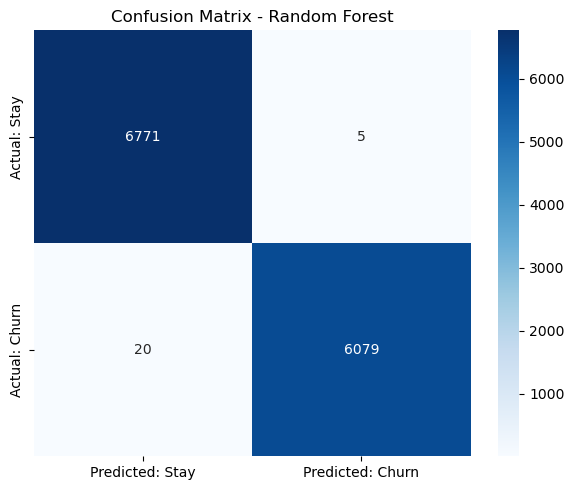

True Negatives (correctly predicted stay):    6771
False Positives (false alarm - predicted churn, actually stayed): 5
False Negatives (missed churner - predicted stay, actually churned): 20
True Positives (correctly predicted churn):   6079


In [5]:
best_pred = predictions[best_model_name]
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted stay):    {tn}")
print(f"False Positives (false alarm - predicted churn, actually stayed): {fp}")
print(f"False Negatives (missed churner - predicted stay, actually churned): {fn}")
print(f"True Positives (correctly predicted churn):   {tp}")

**Which mistake matters more here?** False Negatives (missed churners) are
usually the costlier mistake in a real business -- that customer leaves with zero
warning and zero chance for a retention offer. False Positives (false alarms) just
mean someone gets a retention email they didn't need -- mildly wasteful, not
damaging. Compare the FP and FN counts above: whichever is higher tells you where
this specific model's weakness lies, and that's worth calling out directly in your
final write-up.

## Task 14: Feature Importance

Random Forest can report exactly which features it leaned on most when making its
decisions. This is the moment of truth for Phase 2 -- back then, `Payment Delay`
and `Support Calls` stood out by far as the strongest predictors, both by
correlation and by visible churn-rate thresholds.

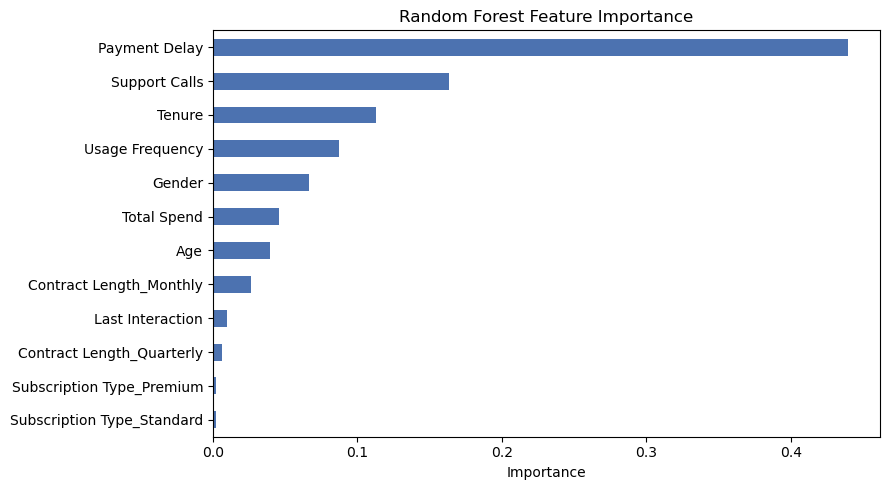

Payment Delay                 0.4398
Support Calls                 0.1635
Tenure                        0.1129
Usage Frequency               0.0871
Gender                        0.0663
Total Spend                   0.0454
Age                           0.0395
Contract Length_Monthly       0.0265
Last Interaction              0.0094
Contract Length_Quarterly     0.0061
Subscription Type_Premium     0.0018
Subscription Type_Standard    0.0018
dtype: float64


In [6]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X_train_prep.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='#4C72B0')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.round(4))

**Compare this ranking to Phase 2's correlation findings.** If `Payment Delay`
and `Support Calls` land at or near the top here too, that's two independent
methods (correlation in Phase 2, and the model's own learned importance here)
agreeing on the same conclusion -- a strong, well-supported finding for your
write-up. If the order is different, that's worth noting and explaining rather
than ignoring.

## Task 15: Manual Improvement

Before letting an automated search take over (Task 16), we try adjusting a couple
of settings by hand to build intuition for what they actually do:
- **`n_estimators`** -- how many trees to build (more trees = more stable
  predictions, but slower and with diminishing returns).
- **`max_depth`** -- how deep each tree is allowed to grow (deeper = can capture
  more complex patterns, but risks memorizing the training data instead of
  learning general rules -- this is called overfitting).

In [7]:
# Baseline (from Task 12) vs a manually adjusted version
rf_baseline_f1 = f1_score(y_test, predictions['Random Forest'])

rf_manual = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42
)
rf_manual.fit(X_train_prep, y_train)
rf_manual_pred = rf_manual.predict(X_test_prep)
rf_manual_f1 = f1_score(y_test, rf_manual_pred)

print(f"Baseline Random Forest F1-score:        {rf_baseline_f1:.4f}")
print(f"Manually adjusted Random Forest F1-score: {rf_manual_f1:.4f}")
print(f"Change: {rf_manual_f1 - rf_baseline_f1:+.4f}")

Baseline Random Forest F1-score:        0.9979
Manually adjusted Random Forest F1-score: 0.9976
Change: -0.0003


**Read the change carefully.** A small positive change means the manual
adjustment helped a little. A small negative or near-zero change is a genuinely
useful finding too -- it tells you the default settings were already close to
as good as this model can get without a more systematic search, which is exactly
what Task 16 does next.

## Task 16: Proper Hyperparameter Tuning (GridSearchCV)

Instead of guessing settings by hand, `GridSearchCV` tries every combination in a
defined grid automatically, using cross-validation (splitting the *training* data
further into folds to validate reliably, without ever touching the real test set
during the search). This keeps the final test score honest.

In [8]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_prep, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

Best parameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation F1-score: 0.9975


In [9]:
# Evaluate the tuned model on the real, held-out test set
best_rf = grid_search.best_estimator_
tuned_pred = best_rf.predict(X_test_prep)

tuned_f1 = f1_score(y_test, tuned_pred)
tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)

print("Tuned Random Forest -- final test set performance:")
print(f"  Accuracy:  {tuned_accuracy:.4f}")
print(f"  Precision: {tuned_precision:.4f}")
print(f"  Recall:    {tuned_recall:.4f}")
print(f"  F1-Score:  {tuned_f1:.4f}")
print(f"\nCompared to untuned baseline F1: {rf_baseline_f1:.4f}")
print(f"Improvement: {tuned_f1 - rf_baseline_f1:+.4f}")

Tuned Random Forest -- final test set performance:
  Accuracy:  0.9981
  Precision: 0.9992
  Recall:    0.9969
  F1-Score:  0.9980

Compared to untuned baseline F1: 0.9979
Improvement: +0.0001


**Why the cross-validation score and the final test score can differ slightly:**
`best_score_` is the average F1 across validation folds *within the training data*
during the search. The final numbers above come from the untouched test set,
which is the real, honest measure of how this model performs on data it has
truly never seen in any form. That's the number to actually report as your
model's performance.

---
### ✅ Phase 5 checkpoint

By now you should be able to state, with real evidence:
- Which of the four models performed best, and by which metric
- What kinds of mistakes that model makes (false alarms vs missed churners) and
  which one matters more for the business
- Which features actually drive its predictions, and whether that matches the
  patterns found back in Phase 2
- Whether manual tuning or GridSearchCV improved performance, and by how much

**Next: Phase 6 (Tasks 17-19)** -- wrapping the tuned model into an actual
prediction system: given a new customer's info, output a churn prediction, a
probability, a risk category, and a retention recommendation.